## Seleção de Features

### Dataset Adverstising 

In [1]:
# Carrega o dataset
import numpy as np
import pandas as pd

data = pd.read_csv('http://www-bcf.usc.edu/~gareth/ISL/Advertising.csv', index_col=0)

In [2]:
# Cria uma lista com 3 features
feature_cols = ['TV', 'radio', 'newspaper']

# Seleciona um subset do DataFrame com a lista de features 
X = data[feature_cols]

# Seleciona a coluna Sales como resposta
y = data.sales

** Devemos manter a coluna newspaper na regressão? **

In [3]:
# 10-fold CV com todas as 3 features
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lm = LinearRegression()
scores = cross_val_score(lm, X, y, cv=10, scoring='neg_mean_squared_error')
print(scores)

[-3.56038438 -3.29767522 -2.08943356 -2.82474283 -1.3027754  -1.74163618
 -8.17338214 -2.11409746 -3.04273109 -2.45281793]


/Users/alexandre/anaconda3/lib/python3.6/site-packages/sklearn/linear_model/base.py:509: RuntimeWarning: internal gelsd driver lwork query error, required iwork dimension not returned. This is likely the result of LAPACK bug 0038, fixed in LAPACK 3.2.2 (released July 21, 2010). Falling back to 'gelss' driver.
  linalg.lstsq(X, y)


In [4]:
# Ajusta o sinal dos scores MSE
mse_scores = -scores
print(mse_scores)

[3.56038438 3.29767522 2.08943356 2.82474283 1.3027754  1.74163618
 8.17338214 2.11409746 3.04273109 2.45281793]


In [5]:
# Converte de MSE para RMSE
rmse_scores = np.sqrt(mse_scores)
print(rmse_scores)

[1.88689808 1.81595022 1.44548731 1.68069713 1.14139187 1.31971064
 2.85891276 1.45399362 1.7443426  1.56614748]


In [6]:
# Calcula o RMSE médio
print(rmse_scores.mean())

1.6913531708051803


In [7]:
# 10-fold CV com 2 features (excluindo newspaper)
feature_cols = ['TV', 'radio']
X = data[feature_cols]
print(np.sqrt(-cross_val_score(lm, X, y, cv=10, scoring='neg_mean_squared_error')).mean())

1.6796748419090766


** Verificando **

Método estatístico univariado para selecionar as melhores features:
- `SelectKBest` remove todas as features exceto as top-k com melhor score
- `f_regression` estima o grau de dependencia linear entre 2 variáveis aleatórias

In [8]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

feature_cols = ['TV', 'radio', 'newspaper']
X = data[feature_cols]
print('Formato original {}'.format(X.shape))

X_new = SelectKBest(f_regression, k=2).fit_transform(X, y)
print('Formato sem a feature newspaper {}'.format(X_new.shape))

Formato original (200, 3)
Formato sem a feature newspaper (200, 2)


### Dataset Iris

In [9]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
iris = load_iris()
X, y = iris.data, iris.target
X.shape

(150, 4)

In [10]:
X_new = SelectKBest(chi2, k=2).fit_transform(X, y)
X_new.shape

(150, 2)

### Comparando F-test e MI

Considere o seguinte cenário:

- 3 features (x1, x2, x3) distribuídas entre 0 e 1
- função entre os labels e as features: y = x1 + sin(6 * pi * x2) + 0.1 * N(0, 1)

Note que:

- x3 é irrelevante
- x1 possui uma dependência linear
- x2 possui uma dependência não-linear

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression, mutual_info_regression

In [12]:
# features
np.random.seed(0)
X = np.random.rand(1000, 3)
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000)

In [13]:
# estima o grau de dependência F-test normalizada
f_test, _ = f_regression(X, y)
f_test /= np.max(f_test)

In [14]:
# estima o grau de dependência MI (mutual information) normalizada
mi = mutual_info_regression(X, y)
mi /= np.max(mi)

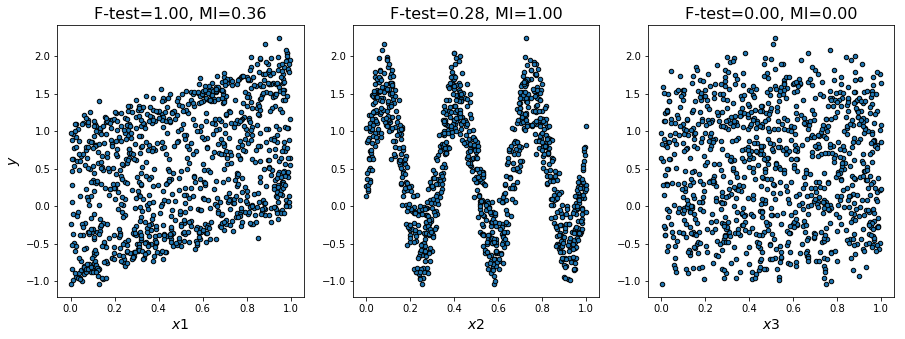

In [15]:
# Plota figura comparando
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, i], y, edgecolor='black', s=20)
    plt.xlabel("$x{}$".format(i + 1), fontsize=14)
    if i == 0:
        plt.ylabel("$y$", fontsize=14)
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]),
              fontsize=16)
plt.show()